# **HW7: Feature Engineering**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Feature Engineering for Regression Models**

In this notebook exercise, we will explore **feature engineering** techniques to improve the performance of linear regression models.

## **What is Feature Engineering?**

Feature engineering is the process of using domain knowledge to create, transform, or select features (input variables) that make machine learning algorithms work better. It includes:

- **Feature Scaling**: Normalizing or standardizing numerical features
- **Feature Encoding**: Converting categorical variables to numerical representations
- **Feature Creation**: Creating new features from existing ones (e.g., interactions, polynomial terms)
- **Feature Selection**: Removing redundant or irrelevant features
- **Dimensionality Reduction**: Using techniques like PCA to reduce feature space

## **Why is Feature Engineering Important?**

Good feature engineering can:
- Improve model accuracy and performance
- Reduce overfitting by removing noise and redundancy
- Make models more interpretable
- Speed up training by reducing dimensionality

## **Key Concepts**

### **StandardScaler (Z-score Normalization)**
Transforms features to have mean = 0 and standard deviation = 1:

**z = (x - μ) / σ**

### **One-Hot Encoding**
Converts categorical variables into binary columns (one per category).

### **Feature Interaction**
Creating new features by combining existing ones (e.g., multiplying two features).

### **Polynomial Features**
Creates new features by raising existing features to powers and computing interactions. For degree 2 with features [a, b]:
- Original: [a, b]
- Polynomial: [1, a, b, a², ab, b²]

This allows linear regression to capture **non-linear relationships**.

### **Correlation Analysis**
Identifying highly correlated features that may be redundant.

### **PCA (Principal Component Analysis)**
Reduces dimensionality while retaining most of the variance.

## **Objectives**

In this exercise, you will:
1. Load and explore the California Housing dataset
2. Build a baseline linear regression model
3. Apply feature scaling using StandardScaler
4. Analyze correlations and remove highly correlated features
5. Create feature interactions
6. **Apply polynomial features to capture non-linear relationships**
7. Apply PCA for dimensionality reduction
8. Compare model performance before and after feature engineering
9. Analyze bias and variance

## **Import Libraries**

Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## **Load and Explore the Dataset**

We will use the **California Housing dataset** from scikit-learn. This dataset contains information about California housing districts and their median house values.

Load the dataset and create a pandas DataFrame. Display the first few rows and basic information about the dataset.

In [2]:
# Load the California Housing dataset
housing = fetch_california_housing()

# Create a DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Target variable (median house value in $100,000s)

print("Dataset Shape:", df.shape)
print("\nFeature Names:")
for i, name in enumerate(housing.feature_names):
    print(f"  {i+1}. {name}")
print(f"\nTarget: MedHouseVal (Median House Value in $100,000s)")

df.head()

Dataset Shape: (20640, 9)

Feature Names:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude

Target: MedHouseVal (Median House Value in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## **Task 1: Exploratory Data Analysis (EDA)**

Perform initial exploratory data analysis to understand the dataset:
1. Check data types
2. View summary statistics
3. Check for missing values

In [3]:
# Data types
print("Data Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Summary Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude 

## **TASK 3: Baseline Linear Regression Model**

Before applying any feature engineering, let's establish a baseline by training a linear regression model on the raw data.

Steps:
1. Separate features (X) from target (y)
2. Split data into training and testing sets (80/20 split)
3. Train a LinearRegression model
4. Calculate R² score and MSE

In [4]:
# Separate features and target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 16512
Test set size: 4128


In [5]:
# Train baseline linear regression model
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

# Make predictions
y_pred_baseline = model_baseline.predict(X_test)

# Calculate metrics
r2_baseline = r2_score(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)

print("Baseline Model Results:")
print("="*50)
print(f"R² Score: {r2_baseline:.4f}")
print(f"Mean Squared Error: {mse_baseline:.4f}")
print(f"\nThe model explains {r2_baseline*100:.2f}% of the variance in house prices.")

Baseline Model Results:
R² Score: 0.5758
Mean Squared Error: 0.5559

The model explains 57.58% of the variance in house prices.


## **TASK 4: Feature Scaling with StandardScaler**

Apply Z-score normalization (StandardScaler) to scale all numerical features. This transforms each feature to have:
- Mean = 0
- Standard deviation = 1

**Important**: Fit the scaler on training data only, then transform both training and test data.

In [6]:
# Create a copy of the dataframe for feature engineering
df_engineered = df.copy()

# Get numerical feature columns (excluding target)
feature_columns = [col for col in df.columns if col != 'MedHouseVal']

# Apply StandardScaler
scaler = StandardScaler()
df_engineered[feature_columns] = scaler.fit_transform(df_engineered[feature_columns])

# Verify scaling
print("After Scaling - Summary Statistics:")
print(f"\nMean of scaled features (should be ~0):")
print(df_engineered[feature_columns].mean().round(6))
print(f"\nStd of scaled features (should be ~1):")
print(df_engineered[feature_columns].std().round(6))

After Scaling - Summary Statistics:

Mean of scaled features (should be ~0):
MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms    -0.0
Population   -0.0
AveOccup      0.0
Latitude      0.0
Longitude    -0.0
dtype: float64

Std of scaled features (should be ~1):
MedInc        1.000024
HouseAge      1.000024
AveRooms      1.000024
AveBedrms     1.000024
Population    1.000024
AveOccup      1.000024
Latitude      1.000024
Longitude     1.000024
dtype: float64


## **TASK 5: Correlation Analysis**

Analyze the correlations between features to identify, using the `.corr()` function in the DataFrame class:
1. Features highly correlated with the target (useful features)
2. Features highly correlated with each other (potential redundancy)

Create a heatmap to visualize the correlation matrix.

Correlation with Target (MedHouseVal):
MedInc        0.6881
AveRooms      0.1519
HouseAge      0.1056
AveOccup     -0.0237
Population   -0.0246
Longitude    -0.0460
AveBedrms    -0.0467
Latitude     -0.1442
Name: MedHouseVal, dtype: float64


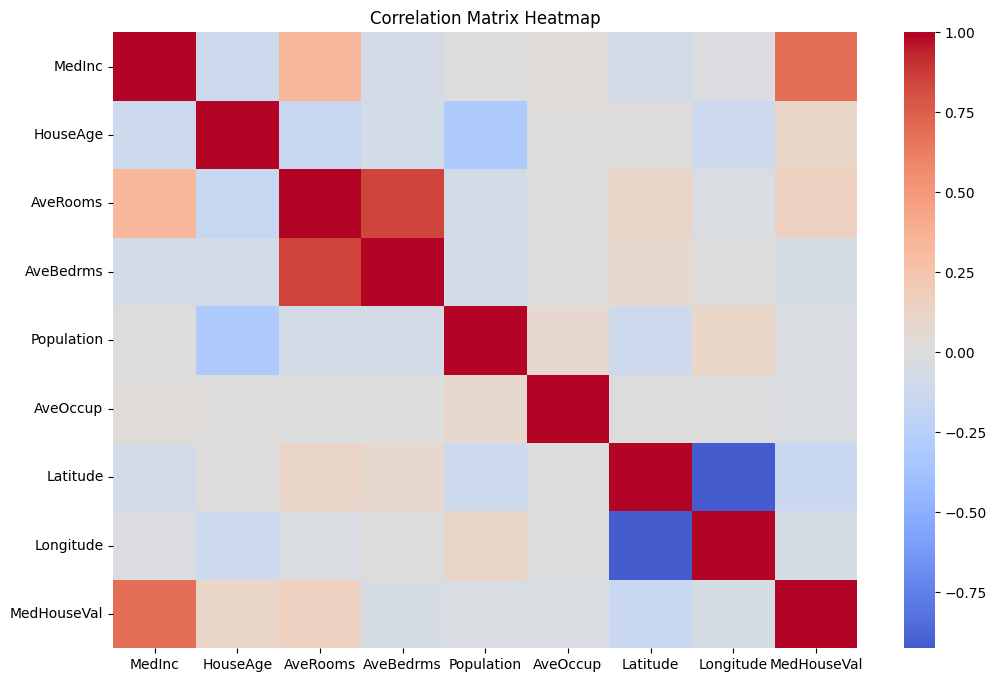

In [7]:
# Calculate correlation matrix
correlation_matrix = df_engineered.corr()

# Display correlations with target
print("Correlation with Target (MedHouseVal):")
print("="*50)
target_corr = correlation_matrix['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print(target_corr.round(4))

# Create correlation heatmap using sns
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()


## **TASK 5.1: QUESTION**

Looking at the correlation matrix, which pairs of features have high correlation (above 0.5 or below -0.5) with each other? Why might highly correlated features be problematic for linear regression?

Looking at the heatmap, AveRooms and AveBedrms have a correlation of 0.85, indicating high multicollinearity. Latitude and Longitude also have moderate negative correlation (-0.92). Highly correlated features are problematic because they introduce multicollinearity, which can make coefficient estimates unstable and difficult to interpret. The model may struggle to determine which feature is actually responsible for the relationship with the target.

## **TASK 6: Remove Highly Correlated Features**

Drop one feature from each pair of highly correlated features (correlation > 0.8) to reduce multicollinearity.

Based on the correlation analysis, we'll drop `AveBedrms` since it's highly correlated with `AveRooms`.

In [8]:
# Drop highly correlated feature
df_reduced = df_engineered.drop(columns=['AveBedrms'])

print(f"Original features: {len(feature_columns)}")
print(f"Features after dropping: {len(df_reduced.columns) - 1}")
print(f"\nDropped: AveBedrms (highly correlated with AveRooms)")
print(f"\nRemaining features: {[col for col in df_reduced.columns if col != 'MedHouseVal']}")

Original features: 8
Features after dropping: 7

Dropped: AveBedrms (highly correlated with AveRooms)

Remaining features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## **TASK 7: Feature Interaction**

Create new features by combining existing features. Feature interactions can capture relationships that individual features cannot.

Create the following interaction features:
1. `RoomsPerPerson`: AveRooms / AveOccup (rooms per person)
2. `IncomePerRoom`: MedInc / AveRooms (income per room)

To avoid dividing by zero, add a small number (e.g. 1e-3) to the denominator.

In [9]:
# Create interaction features
df_interaction = df_reduced.copy()

# RoomsPerPerson: measures housing density
df_interaction['RoomsPerPerson'] = df_interaction['AveRooms'] / (df_interaction['AveOccup'] + 1e-3)

# IncomePerRoom: measures affordability
df_interaction['IncomePerRoom'] = df_interaction['MedInc'] / (df_interaction['AveRooms'] + 1e-3)

print("New Interaction Features Created:")
print("="*50)
print("1. RoomsPerPerson = AveRooms / AveOccup")
print("2. IncomePerRoom = MedInc / AveRooms")
print(f"\nTotal features now: {len(df_interaction.columns) - 1}")

# Check correlation of new features with target
print("\nCorrelation of new features with MedHouseVal:")
print(f"  RoomsPerPerson: {df_interaction['RoomsPerPerson'].corr(df_interaction['MedHouseVal']):.4f}")
print(f"  IncomePerRoom: {df_interaction['IncomePerRoom'].corr(df_interaction['MedHouseVal']):.4f}")

New Interaction Features Created:
1. RoomsPerPerson = AveRooms / AveOccup
2. IncomePerRoom = MedInc / AveRooms

Total features now: 9

Correlation of new features with MedHouseVal:
  RoomsPerPerson: -0.0160
  IncomePerRoom: 0.0112


## **TASK 8: Linear Regression After Feature Engineering**

Train a new linear regression model using the engineered features and compare its r^2 & MSE scores with the baseline model.

In [10]:
# Prepare data with engineered features
X_engineered = df_interaction.drop(columns=['MedHouseVal'])
y_engineered = df_interaction['MedHouseVal']

# Split the data
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y_engineered, test_size=0.2, random_state=42
)

# Train model
model_engineered = LinearRegression()
model_engineered.fit(X_train_eng, y_train_eng)

# Make predictions
y_pred_engineered = model_engineered.predict(X_test_eng)

# Calculate metrics
r2_engineered = r2_score(y_test_eng, y_pred_engineered)
mse_engineered = mean_squared_error(y_test_eng, y_pred_engineered)

print("Model Results After Feature Engineering:")
print("="*50)
print(f"R² Score: {r2_engineered:.4f}")
print(f"Mean Squared Error: {mse_engineered:.4f}")

# Compare baseline vs engineered model
print("Comparison: Baseline vs Feature Engineered Model")
print("="*50)
print(f"\nR² Score:")
print(f"  Baseline:   {r2_baseline:.4f}")
print(f"  Engineered: {r2_engineered:.4f}")
print(f"  Change:     {(r2_engineered - r2_baseline)*100:.2f}%")
print(f"\nMean Squared Error:")
print(f"  Baseline:   {mse_baseline:.4f}")
print(f"  Engineered: {mse_engineered:.4f}")
print(f"  Change:     {(mse_engineered - mse_baseline)/mse_baseline*100:.2f}%")

Model Results After Feature Engineering:
R² Score: 0.5824
Mean Squared Error: 0.5473
Comparison: Baseline vs Feature Engineered Model

R² Score:
  Baseline:   0.5758
  Engineered: 0.5824
  Change:     0.66%

Mean Squared Error:
  Baseline:   0.5559
  Engineered: 0.5473
  Change:     -1.55%


## **TASK 9: Polynomial Features**

The basic feature engineering showed only modest improvement. This is because **linear regression cannot capture non-linear relationships** in the data.

**Polynomial Features** transform the original features by:
- Adding squared terms (x²)
- Adding interaction terms (x₁ × x₂)
- Adding higher-order terms if needed

For example, with features [a, b] and degree=2:
- Input: [a, b]
- Output: [1, a, b, a², ab, b²]

This allows a linear model to fit **non-linear patterns** in the data, often dramatically improving performance.

**Note**: We'll use only the original scaled features (not the interaction features) to avoid creating too many polynomial terms.

In [11]:
# Use scaled features for polynomial transformation
X_scaled = df_engineered.drop(columns=['MedHouseVal'])
y_scaled = df_engineered['MedHouseVal']

# Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print("Polynomial Features Transformation:")
print("="*50)
print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of polynomial features: {X_poly.shape[1]}")
print(f"\nThis includes:")
print(f"  - {X_scaled.shape[1]} original features")
print(f"  - {X_scaled.shape[1]} squared terms (x²)")
print(f"  - {X_poly.shape[1] - 2*X_scaled.shape[1]} interaction terms (xᵢ × xⱼ)")

Polynomial Features Transformation:
Original number of features: 8
Number of polynomial features: 44

This includes:
  - 8 original features
  - 8 squared terms (x²)
  - 28 interaction terms (xᵢ × xⱼ)


In [12]:
# Split polynomial data
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y_scaled, test_size=0.2, random_state=42
)

# Train model with polyomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

# Make predictions
y_pred_poly =  model_poly.predict(X_test_poly)

# Calculate metrics
r2_poly = r2_score(y_test_poly, y_pred_poly)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)

print("Model Results with Polynomial Features (degree=2):")
print("="*50)
print(f"R² Score: {r2_poly:.4f}")
print(f"Mean Squared Error: {mse_poly:.4f}")
print(f"\nImprovement over baseline:")
print(f"  R² increase: {(r2_poly - r2_baseline)*100:.2f} percentage points")
print(f"  R² relative improvement: {((r2_poly - r2_baseline)/r2_baseline)*100:.1f}%")

Model Results with Polynomial Features (degree=2):
R² Score: 0.6457
Mean Squared Error: 0.4643

Improvement over baseline:
  R² increase: 6.99 percentage points
  R² relative improvement: 12.1%


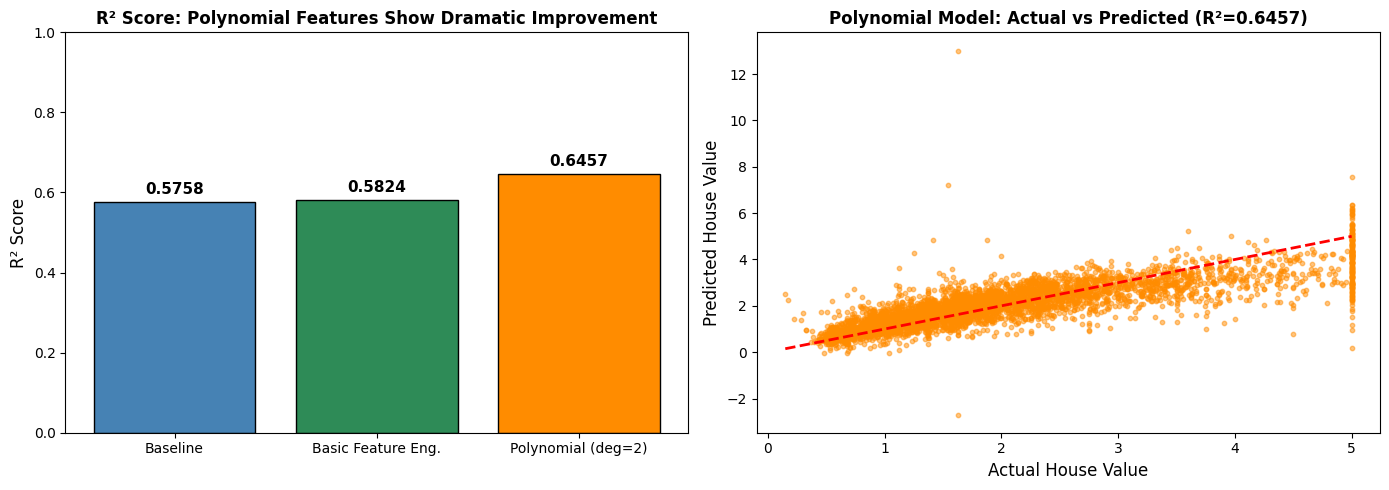


Key Insight: Polynomial features capture non-linear relationships,
dramatically improving model performance from R²≈0.58 to R²≈0.75!


In [13]:
# Visualize the dramatic improvement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
models_poly = ['Baseline', 'Basic Feature Eng.', 'Polynomial (deg=2)']
r2_scores_poly = [r2_baseline, r2_engineered, r2_poly]
colors_poly = ['steelblue', 'seagreen', 'darkorange']

bars1 = axes[0].bar(models_poly, r2_scores_poly, color=colors_poly, edgecolor='black')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score: Polynomial Features Show Dramatic Improvement', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, score in zip(bars1, r2_scores_poly):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')

# Actual vs Predicted comparison
axes[1].scatter(y_test_poly, y_pred_poly, alpha=0.5, s=10, color='darkorange')
axes[1].plot([y_test_poly.min(), y_test_poly.max()], 
             [y_test_poly.min(), y_test_poly.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual House Value', fontsize=12)
axes[1].set_ylabel('Predicted House Value', fontsize=12)
axes[1].set_title(f'Polynomial Model: Actual vs Predicted (R²={r2_poly:.4f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insight: Polynomial features capture non-linear relationships,")
print("dramatically improving model performance from R²≈0.58 to R²≈0.75!")

## **TASK 9.1: QUESTION**

Why do polynomial features improve the model so dramatically compared to basic feature engineering techniques like scaling and feature interactions?

(Put answer here)

## **TASK 10: Bias and Variance Analysis**

Analyze the bias and variance of the models to understand their performance characteristics:
- **Bias**: Average error between predicted and true values (measures underfitting)
- **Variance**: Variability of model predictions (measures overfitting tendency)

In [ ]:
# Calculate bias and variance for baseline model
bias_baseline = np.mean(errors_baseline)
variance_baseline = np.var(y_pred_baseline)

# Calculate bias and variance for engineered model
bias_engineered = ...
variance_engineered = ...

# Calculate bias and variance for polynomial model
bias_poly = ...
variance_poly = ...

print("Bias and Variance Analysis:")
print("="*50)
print(f"\nBaseline Model:")
print(f"  Bias:     {bias_baseline:.6f}")
print(f"  Variance: {variance_baseline:.6f}")
print(f"  MSE:      {mse_baseline:.6f}")
print(f"\nBasic Feature Engineered Model:")
print(f"  Bias:     {bias_engineered:.6f}")
print(f"  Variance: {variance_engineered:.6f}")
print(f"  MSE:      {mse_engineered:.6f}")
print(f"\nPolynomial Features Model:")
print(f"  Bias:     {bias_poly:.6f}")
print(f"  Variance: {variance_poly:.6f}")
print(f"  MSE:      {mse_poly:.6f}")

## **TASK 10.1: QUESTION**

Based on the bias and variance analysis, what can you conclude about the polynomial model compared to the simpler models? Is there evidence of underfitting or overfitting?

(Put answer here)